In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import scienceplots

plt.style.use('science')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 10

In [19]:
errors_good = np.array(
    [
        0.006737,
        0.006828,
        0.007091,
        0.006997,
        0.006610,
        0.006795,
        0.006872,
        0.006725,
        0.006873,
        0.006817,
    ]
)
errors_bad = np.array(
    [
        0.007432,
        0.007455,
        0.008369,
        0.007183,
        0.007653,
        0.008856,
        0.007531,
        0.007624,
        0.007457,
        0.008424,
    ]
)


In [20]:
errors = np.concatenate([errors_good, errors_bad])
labels = np.array([0] * len(errors_good) + [1] * len(errors_bad))  # 0 = good, 1 = bad
fpr, tpr, thresholds = roc_curve(labels, errors)

In [21]:
thresholds, fpr, tpr

(array([     inf, 0.008856, 0.007183, 0.00661 ]),
 array([0., 0., 0., 1.]),
 array([0. , 0.1, 1. , 1. ]))

In [22]:
j_scores = tpr - fpr

In [23]:
j_scores

array([0. , 0.1, 1. , 0. ])

In [24]:
best_idx = np.argmax(j_scores)

In [25]:
best_idx

np.int64(2)

In [26]:
best_threshold = thresholds[best_idx]

In [27]:
best_threshold

np.float64(0.007183)

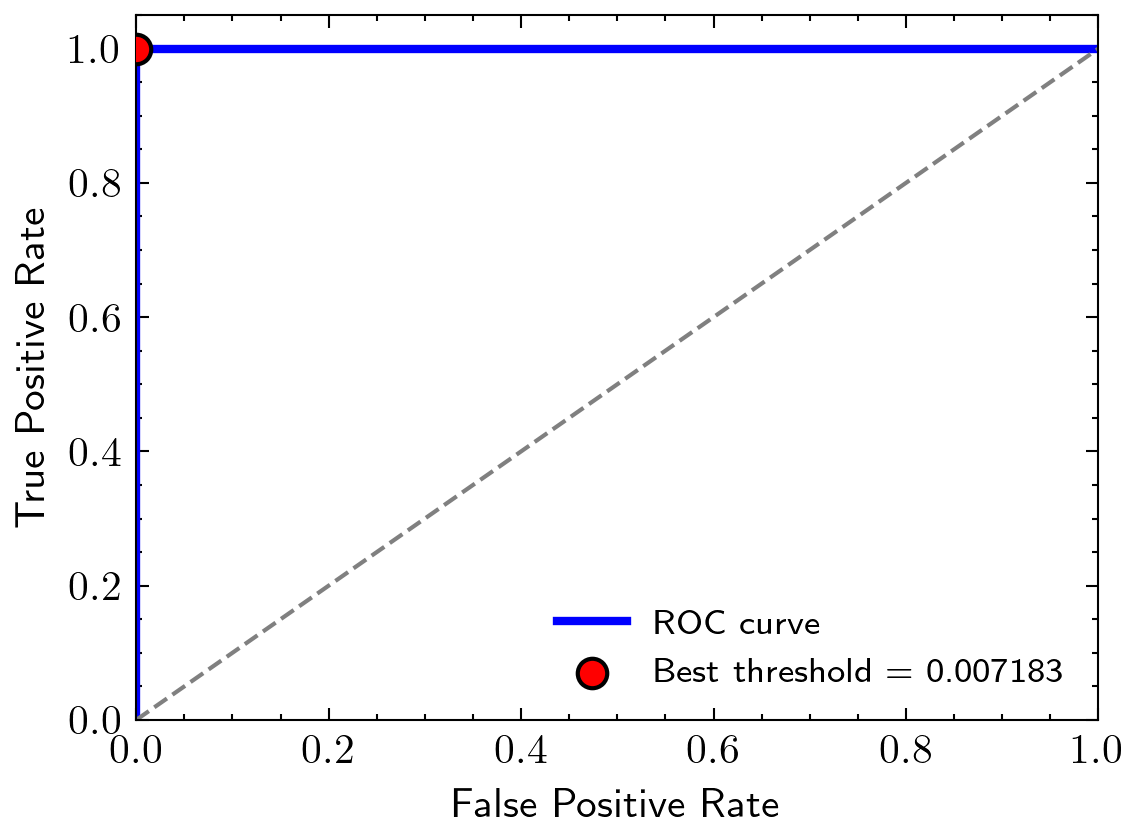

In [36]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

ax.plot(fpr, tpr, lw=2, label="ROC curve", color="blue")

ax.scatter(
    fpr[best_idx],
    tpr[best_idx],
    color="red",
    edgecolor="black",
    s=50,
    zorder=5,
    label=f"Best threshold = {best_threshold}",
)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

ax.legend(loc="lower right", fontsize="small")

plt.tight_layout()
plt.show()
